# **TRATAMENTOS COM O DF AQUI**

Aqui ficam os tratamentos de ETL (análise exploratória, outliers e etc) usando a extensão do google colab no vscode permitindo que possa ser aberto no colab na web e no vscode.

## Descrição do Dataset
Este conjunto de dados representa as chamadas policiais de emergência e não emergência para o 911. Trata-se de um arquivo CSV simples com cerca de **932K** de registros

Link do dataset: [911 - Service](https://www.kaggle.com/datasets/ahmadrafiee/911-calls-for-service-metadata-1-million-record)

## Setup

In [ ]:
!pip install kagglehub pandas numpy matplotlib seaborn pathlib tqdm ipywidgets kagglehub[pandas-datasets]

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import kagglehub
from kagglehub import KaggleDatasetAdapter
# from .autonotebook import tqdm as notebook_tqdm
import os
import shutil

In [3]:
# 1. Configuração de Caminhos
PROJECT_ROOT = Path.cwd().parent 
RAW_DIR = PROJECT_ROOT / "data" / "raw"
RAW_FILE_PATH = RAW_DIR / "911.csv"

# Garante que a pasta de destino exista
RAW_DIR.mkdir(parents=True, exist_ok=True)

if RAW_FILE_PATH.exists():
    print(f"✅ Arquivo já existe em {RAW_FILE_PATH}. Carregando...")
    df = pd.read_csv(RAW_FILE_PATH, sep=None, engine='python', encoding='utf-8')
else:
    print("⏳ Iniciando download e organização dos arquivos...")
    try:
        # 2. Download para o cache do sistema
        download_path = kagglehub.dataset_download("ahmadrafiee/911-calls-for-service-metadata-1-million-record")
        
        # 3. Localiza o arquivo CSV no cache
        files = [f for f in os.listdir(download_path) if f.endswith('.csv')]
        if not files:
            raise FileNotFoundError("Nenhum CSV encontrado no download.")
        
        temp_csv_path = Path(download_path) / files[0]

        # 4. Move o arquivo do cache para a sua pasta data/raw/
        # Isso resolve o problema de "estar em outro diretório"
        shutil.copy(temp_csv_path, RAW_FILE_PATH)
        print(f"📂 Arquivo movido com sucesso para: {RAW_FILE_PATH}")

        # 5. Leitura com detecção automática de separador
        # sep=None faz o pandas descobrir se é vírgula ou ponto-e-vírgula
        df = pd.read_csv(RAW_FILE_PATH, sep=None, engine='python', on_bad_lines='warn')
        
        print(f"🎯 Dados carregados com sucesso! Total de linhas: {len(df)}")

    except Exception as e:
        print(f"❌ Erro: {e}")

if 'df' in locals():
    print(df.head())

✅ Arquivo já existe em c:\Users\User\Documents\Vscode\Data-Science\project-ds\data\raw\911.csv. Carregando...
   recordId           callKey            callDateTime priority district  \
0         1  10CC9DA95FF34377  2021/01/04 16:33:00+00      Low      TRU   
1         2  10CC9DA95FF3518A  2021/01/04 17:34:00+00   Medium       WD   
2         3  10CC9DA95FF35312  2021/01/04 17:40:00+00      Low       CD   
3         4  10CC9DA95FF3543D  2021/01/04 17:45:00+00   Medium       SD   
4         5  10CC9DA95FF4659A  2021/01/05 13:11:00+00      Low      TRU   

     description  callNumber      incidentLocation  \
0    HIT AND RUN  P210041843         3500 AILSA AV   
1      NARCOTICS  P210042073     1700 N CALHOUN ST   
2          OTHER  P210042088    2000 DRUID HILL AV   
3      NARCOTICS  P210042103       600 S PAYSON ST   
4  DESTRUCT PROP  P210051288  3600 CHESTERFIELD AV   

                            location         Neighborhood PoliceDistrict  \
0         3500 AILSA AV BALTIMORE MD  

## Infos Básicas

In [17]:
df

,recordId,callKey,callDateTime,priority,district,description,callNumber,incidentLocation,location,Neighborhood,PoliceDistrict,PolicePost,CouncilDistrict,SheriffDistricts,Community_Statistical_Areas,Census_Tracts,ZIPCode,NeedsSync,ESRI_OID,Unnamed: 19
0,1,10CC9DA95FF34377,2021/01/04 16:33:00+00,Low,TRU,HIT AND RUN,P210041843,3500 AILSA AV,3500 AILSA AV BALTIMORE MD,Waltherson,Northeastern,426.0,2.0,D4,Lauraville,Census Tract 2701.02,21214.0,0,79,NaN
1,2,10CC9DA95FF3518A,2021/01/04 17:34:00+00,Medium,WD,NARCOTICS,P210042073,1700 N CALHOUN ST,1700 N CALHOUN ST BALTIMORE MD,Sandtown-Winchester,Western,742.0,7.0,D9,Sandtown-Winchester/Harlem Park,Census Tract 1501,21217.0,0,80,NaN
2,3,10CC9DA95FF35312,2021/01/04 17:40:00+00,Low,CD,OTHER,P210042088,2000 DRUID HILL AV,2000 DRUID HILL AV BALTIMORE MD,Druid Heights,Central,131.0,11.0,D8,Upton/Druid Heights,Census Tract 1403,21217.0,0,81,NaN
3,4,10CC9DA95FF3543D,2021/01/04 17:45:00+00,Medium,SD,NARCOTICS,P210042103,600 S PAYSON ST,600 S PAYSON ST BALTIMORE MD,Carrollton Ridge,Southern,934.0,9.0,D8,Southwest Baltimore,Census Tract 2003,21223.0,0,82,NaN
4,5,10CC9DA95FF4659A,2021/01/05 13:11:00+00,Low,TRU,DESTRUCT PROP,P210051288,3600 CHESTERFIELD AV,3600 CHESTERFIELD AV BALTIMORE MD,Belair-Edison,Northeastern,432.0,13.0,D6,Belair-Edison,Census Tract 2603.02,21213.0,0,83,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,1048571,6301020A60D52EC9,2021/06/25 01:18:00+00,Medium,SW,SILENT ALARM,P211753534,0 S CULVER ST,0 S CULVER ST BALTIMORE MD,Saint Josephs,Southwestern,842.0,8.0,D10,Allendale/Irvington/S. Hilton,Census Tract 2007.02,21229.0,1,990598,NaN
1048571,1048572,6301020A60D52FCB,2021/06/25 01:22:00+00,Medium,NW,NARCOTICS,P211753545,5400 REISTERSTOWN RD,5400 REISTERSTOWN RD BALTIMORE MD,Woodmere,Northwestern,623.0,5.0,D1,Glen-Fallstaff,Census Tract 2801.01,21215.0,1,990599,NaN
1048572,1048573,6301020A60D53622,2021/06/25 01:49:00+00,Low,ND,AUTO ACCIDENT,P211753666,E 0TH ST/N CHARLES ST,E 0TH ST and N CHARLES ST BALTIMORE MD,Charles Village,Northern,512.0,12.0,D2,Greater Charles Village/Barclay,Census Tract 1206,21218.0,1,990600,NaN
1048573,1048574,6301020A60D53995,2021/06/25 02:04:00+00,Low,SE,HIT AND RUN,P211753713,2000 BLK FLEET ST,2000 BLK FLEET ST BALTIMORE MD,Fells Point,Southeastern,213.0,1.0,D6,Fells Point,Census Tract 203,21231.0,1,990601,NaN


In [18]:
df.describe()

,recordId,PolicePost,CouncilDistrict,ZIPCode,NeedsSync,ESRI_OID,Unnamed: 19
count,1.048575e+06,1.047557e+06,1.047605e+06,1.047077e+06,1.048575e+06,1.048575e+06,0.0
mean,5.242880e+05,5.157490e+02,8.070009e+00,2.121717e+04,9.988356e-01,4.686885e+05,NaN
std,3.026977e+05,2.653806e+02,3.868166e+00,1.062272e+01,3.410400e-02,2.989310e+05,NaN
min,1.000000e+00,1.110000e+02,1.000000e+00,2.120100e+04,0.000000e+00,2.700000e+01,NaN
25%,2.621445e+05,3.110000e+02,5.000000e+00,2.121100e+04,1.000000e+00,2.041705e+05,NaN
50%,5.242880e+05,5.130000e+02,9.000000e+00,2.121700e+04,1.000000e+00,4.663150e+05,NaN
75%,7.864315e+05,7.330000e+02,1.100000e+01,2.122400e+04,1.000000e+00,7.284585e+05,NaN
max,1.048575e+06,9.430000e+02,1.400000e+01,2.128700e+04,1.000000e+00,9.906020e+05,NaN


## Verificação de Outliers

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['callDateTime'])
plt.title('Identificação Visual de Outliers (Boxplot)')
plt.show()

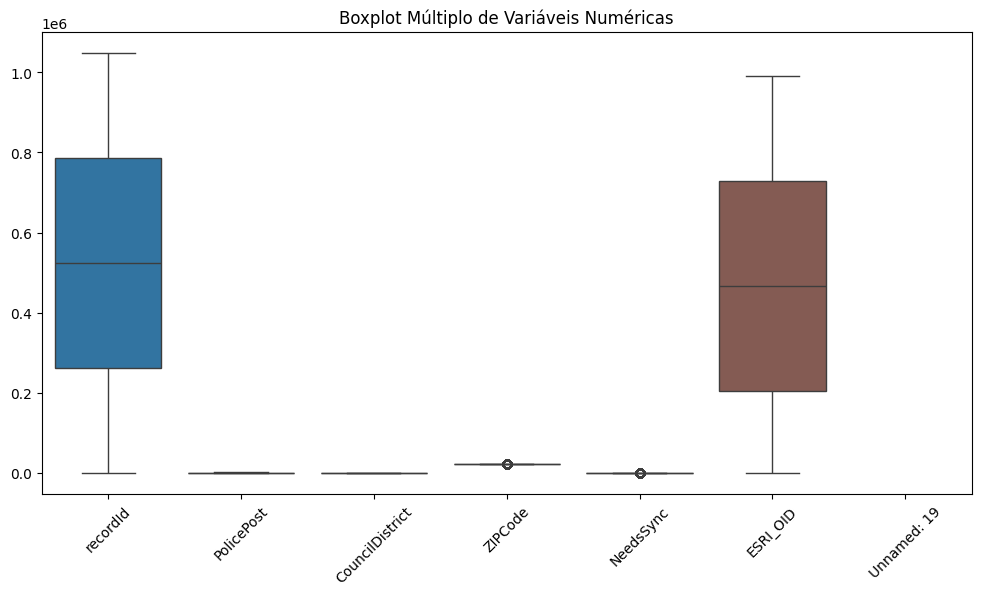

In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include=['float64', 'int64']))
plt.title('Boxplot Múltiplo de Variáveis Numéricas')
plt.xticks(rotation=45) # Rotaciona os nomes para melhor leitura
plt.show()

## Métricas e Visualizações